# Práctica 7 — Word Embeddings con Word2Vec

## Introducción

En esta práctica aprenderemos a entrenar y explorar **embeddings de palabras** (vectores numéricos que representan palabras) utilizando el algoritmo **Word2Vec** sobre un corpus de letras de canciones en español.

### ¿Qué es un word embedding?

Un *word embedding* es una representación densa de una palabra como un vector de números reales en un espacio de alta dimensión (típicamente 50–300 dimensiones). A diferencia de codificaciones clásicas como *one-hot encoding*, los embeddings capturan **relaciones semánticas**: palabras con significados parecidos quedan situadas cerca unas de otras en el espacio vectorial.

Por ejemplo, tras un buen entrenamiento:
- `vec('rey') - vec('hombre') + vec('mujer') ≈ vec('reina')`
- `vec('amor')` estará cerca de `vec('cariño')`, `vec('querer')`, etc.

### ¿Qué es Word2Vec?

Word2Vec (Mikolov et al., 2013) es un algoritmo de aprendizaje no supervisado que entrena una red neuronal superficial para predecir el contexto de cada palabra. Existen dos variantes arquitectónicas:

| Arquitectura | Tarea de entrenamiento | Ideal para |
|---|---|---|
| **CBOW** (Continuous Bag of Words) | Predice la palabra central a partir del contexto | Corpus grandes |
| **Skip-Gram** | Predice el contexto a partir de la palabra central | Corpus pequeños, palabras raras |

En esta práctica usaremos **Skip-Gram con Negative Sampling (SGNS)**.

### Estructura del notebook

1. Instalación e importaciones
2. Preprocesamiento y tokenización del corpus
3. Callback para registrar la pérdida durante el entrenamiento
4. Entrenamiento del modelo Word2Vec
5. Búsqueda de palabras similares
6. Visualización de embeddings (PCA / t-SNE)
7. Exportación a TSV para TensorFlow Projector
8. Ejecución del flujo completo

---
## Celda 1 — Instalación de dependencias e importaciones

Antes de importar nada, instalamos **gensim**, la librería principal que usaremos para Word2Vec.  
El resto de librerías ya suelen estar disponibles en entornos como Google Colab:

| Librería | Uso en esta práctica |
|---|---|
| `gensim` | Entrenamiento y manejo del modelo Word2Vec |
| `torch` / `torch.nn.functional` | Operaciones tensoriales para embeddings propios |
| `sklearn` | PCA y t-SNE para reducción de dimensionalidad |
| `nltk` | Lista de *stopwords* en español |
| `matplotlib` | Visualización de gráficas |
| `numpy` | Álgebra lineal y manipulación de arrays |
| `re`, `string`, `io` | Procesamiento de texto y archivos |

In [1]:
# Instalamos gensim si no está disponible.
# En Google Colab es habitual que no esté preinstalada.
!pip install gensim

# ── Librerías de PyTorch ──────────────────────────────────────────────────────
import torch                        # Framework de deep learning; lo usamos para
                                    # operar con embeddings en formato tensorial.
import torch.nn.functional as F     # Funciones sin estado: normalize, softmax, etc.

# ── Librerías estándar de Python ─────────────────────────────────────────────
import string   # Contiene constantes útiles: string.punctuation = '!"#$%&\'()*+,...'
import io       # Entrada/salida de bajo nivel; lo usamos para escribir TSV en UTF-8.
import re       # Expresiones regulares; necesario para extraer bloques del corpus.

# ── Visualización ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt     # Para graficar la curva de pérdida y los embeddings.

# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.decomposition import PCA       # Análisis de Componentes Principales:
                                            # reducción lineal de dimensionalidad.
from sklearn.manifold import TSNE           # t-SNE: reducción no lineal que preserva
                                            # estructuras de vecindad local.
from sklearn.preprocessing import normalize # Normaliza vectores a norma L2 = 1,
                                            # necesario antes de visualizar.

# ── NLTK (Natural Language Toolkit) ──────────────────────────────────────────
import nltk
from nltk.corpus import stopwords   # Lista de palabras vacías (artículos, preposiciones…)
                                    # que se filtran al visualizar para reducir ruido.

# ── Gensim — Word2Vec ────────────────────────────────────────────────────────
from gensim.models import Word2Vec              # Clase principal del modelo.
from gensim.models.callbacks import CallbackAny2Vec  # Clase base para callbacks
                                                      # que se ejecutan durante el entrenamiento.
from gensim.models import KeyedVectors          # Permite cargar vectores guardados
                                                # sin necesidad de cargar el modelo completo.

# ── NumPy ────────────────────────────────────────────────────────────────────
import numpy as np  # Álgebra lineal y arrays multidimensionales.

# Descargamos la lista de stopwords en español.
# NLTK necesita descargarlos la primera vez; después los cachea localmente.
nltk.download('stopwords')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 51.6 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

---
## Celda 2 — Preprocesamiento del texto

Antes de entrenar Word2Vec, el texto del corpus debe **normalizarse** para reducir el tamaño del vocabulario y mejorar la calidad de los embeddings.

La función `preprocess` aplica tres transformaciones básicas:

1. **Eliminar puntuación**: los signos de puntuación no aportan información semántica y añaden tokens distintos innecesarios (`"amor"` ≠ `"amor,"`).
2. **Convertir a minúsculas**: `"Amor"` y `"amor"` deben ser el mismo token.
3. **Eliminar espacios extremos**: evita tokens vacíos tras el split.

> **Nota sobre el español**: el español tiene signos de apertura de interrogación (`¿`) y exclamación (`¡`) que no están incluidos en `string.punctuation` estándar, por eso los añadimos manualmente.

In [2]:
def preprocess(text):
    """
    Normaliza una cadena de texto para su uso en Word2Vec.

    Pasos:
        1. Elimina toda la puntuación, incluyendo los signos españoles ¿ ¡.
        2. Convierte el texto a minúsculas.
        3. Elimina espacios en blanco al inicio y al final.

    Args:
        text (str): Cadena de texto sin procesar.

    Returns:
        str: Texto limpio y normalizado.

    Ejemplo:
        >>> preprocess('¡Hola, Mundo!')
        'hola mundo'
    """
    # Añadimos los signos de puntuación españoles que no están
    # en el módulo 'string' estándar de Python.
    additional_punctuation = "?¿!¡"

    # Unimos la puntuación estándar ASCII con la española.
    # string.punctuation = '!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'
    all_punctuation = string.punctuation + additional_punctuation

    # str.maketrans('', '', chars) crea una tabla de traducción
    # que elimina todos los caracteres listados en 'chars'.
    # text.translate(tabla) aplica la tabla eficientemente sobre el texto.
    text = text.translate(str.maketrans('', '', all_punctuation))

    # Convertimos a minúsculas para que 'Amor', 'AMOR' y 'amor'
    # sean tratados como el mismo token durante el entrenamiento.
    text = text.lower()

    # Eliminamos espacios iniciales y finales que podrían
    # generar tokens vacíos al hacer .split() más adelante.
    text = text.strip()

    return text


# ── Prueba rápida ─────────────────────────────────────────────────────────────
# Comprobamos que la función funciona como esperamos antes de continuar.
ejemplos = [
    "¡Hola, Mundo!",
    "¿Qué tal estás?",
    "  Espacios   al inicio y al final  ",
]
for ej in ejemplos:
    print(f"Original : {repr(ej)}")
    print(f"Procesado: {repr(preprocess(ej))}")
    print()

Original : '¡Hola, Mundo!'
Procesado: 'hola mundo'

Original : '¿Qué tal estás?'
Procesado: 'qué tal estás'

Original : '  Espacios   al inicio y al final  '
Procesado: 'espacios   al inicio y al final'



---
## Celda 3 — Lectura y tokenización del corpus

El corpus de esta práctica está formado por letras de canciones almacenadas en un fichero `.txt` con una **estructura de marcado personalizada**:

```
<CS>
Primera línea de la canción<EOL>
Segunda línea de la canción<EOL>
...
</CS>
<CS>
...
</CS>
```

- `<CS>` ... `</CS>` delimita cada canción completa.
- `<EOL>` (*End Of Line*) marca el fin de cada verso o línea lírica.

Word2Vec necesita como entrada una **lista de oraciones**, donde cada oración es una **lista de tokens** (palabras). Cada verso del corpus se convierte en una oración, de modo que el modelo aprende contextos dentro de un mismo verso.

### ¿Por qué importa la unidad de contexto?

Word2Vec aprende el significado de una palabra observando las palabras que aparecen en su **ventana de contexto** (las N palabras anteriores y posteriores). Si juntásemos todo el corpus en un único bloque de texto, el modelo podría aprender contextos que cruzan canciones distintas, lo cual no tiene sentido semánticamente.

In [3]:
def read_and_tokenize_wordvec(filename, preprocess_fn=None):
    """
    Lee un corpus de canciones en formato <CS>...</CS> con marcadores <EOL>
    y lo convierte en una lista de oraciones tokenizadas, lista para entrenar Word2Vec.

    Formato del fichero de entrada:
        <CS>
        verso uno<EOL>
        verso dos<EOL>
        </CS>

    Args:
        filename (str): Ruta al fichero de corpus (.txt).
        preprocess_fn (callable, optional): Función de preprocesamiento que se
            aplica a cada verso antes de tokenizar. Si es None, no se aplica
            ningún preprocesamiento.

    Returns:
        all_sentences (list[list[str]]): Lista plana de todas las oraciones.
            Cada oración es una lista de tokens (palabras). Este es el formato
            que espera gensim.Word2Vec como argumento `sentences`.
        songs_dict (dict[int, list[list[str]]]): Diccionario que mapea el
            índice de cada canción a su lista de oraciones. Útil para análisis
            por canción individual.
    """
    # Leemos el fichero completo como una cadena.
    # 'utf-8-sig' elimina automáticamente el BOM (Byte Order Mark) que
    # algunos editores de Windows añaden al principio de los ficheros UTF-8.
    with open(filename, 'r', encoding='utf-8-sig') as f:
        content = f.read()

    # Extraemos todos los bloques de canción con expresiones regulares.
    # re.DOTALL hace que '.' también coincida con saltos de línea '\n',
    # necesario porque las canciones ocupan múltiples líneas.
    # '.*?' es una coincidencia 'lazy' (no greedy): captura lo mínimo posible,
    # evitando fusionar varios bloques <CS>...</CS> en uno.
    song_blocks = re.findall(r'<CS>(.*?)</CS>', content, flags=re.DOTALL)

    all_sentences = []  # Lista plana para el entrenamiento de Word2Vec.
    songs_dict = {}     # Diccionario: índice_canción → lista de sus oraciones.

    for song_idx, block in enumerate(song_blocks):
        song_sentences = []  # Oraciones de esta canción en particular.

        # Dividimos el bloque por el marcador <EOL>.
        # Cada fragmento resultante corresponde a un verso de la canción.
        lines = block.split('<EOL>')

        for line in lines:
            # Eliminamos espacios y saltos de línea sobrantes.
            line = line.strip()

            # Saltamos líneas vacías (pueden aparecer al principio o final del bloque).
            if not line:
                continue

            # Aplicamos la función de preprocesamiento si se proporcionó.
            # Esto normalmente implica quitar puntuación y pasar a minúsculas.
            if preprocess_fn is not None:
                line = preprocess_fn(line)

            # Tokenizamos por espacios en blanco.
            # Para el corpus de canciones esta estrategia simple es suficiente.
            tokens = line.split()

            # Solo añadimos la oración si tiene al menos un token
            # (evitamos listas vacías que confundirían al modelo).
            if tokens:
                song_sentences.append(tokens)
                all_sentences.append(tokens)  # También a la lista global.

        # Guardamos las oraciones de esta canción en el diccionario.
        songs_dict[song_idx] = song_sentences

    print(f"[INFO] Se han analizado {len(song_blocks)} canciones → "
          f"{len(all_sentences)} oraciones en total.")

    return all_sentences, songs_dict

---
## Celda 4 — Callback para registrar la pérdida por época

Durante el entrenamiento de Word2Vec es importante monitorear cómo evoluciona la **función de pérdida** (*loss*) con cada paso del optimizador. Si la pérdida disminuye progresivamente, el modelo está aprendiendo correctamente.

Gensim permite inyectar **callbacks** en el bucle de entrenamiento mediante la clase base `CallbackAny2Vec`. Nosotros creamos `LossLogger`, que:

1. Se ejecuta automáticamente al finalizar cada época.
2. Recupera la pérdida acumulada en esa época.
3. La almacena en una lista para graficarla después.
4. **Reinicia** el contador interno de pérdida de gensim a `0.0` para que la siguiente época comience desde cero (sin este paso, `get_latest_training_loss()` devuelve la pérdida **acumulada** desde el inicio del entrenamiento, no la de la época actual).

> **¿Por qué monitorear la pérdida?**  
> La curva de pérdida nos ayuda a decidir el número óptimo de épocas. Si la pérdida deja de bajar (se estabiliza o incluso sube), continuar entrenando no mejoraría los embeddings y podría causar *overfitting*.

In [4]:
class LossLogger(CallbackAny2Vec):
    """
    Callback de gensim que registra la pérdida de entrenamiento tras cada época.

    Hereda de CallbackAny2Vec, que define los métodos de enganche (hooks)
    disponibles durante el entrenamiento:
        - on_train_begin  : antes de la primera época
        - on_epoch_begin  : al inicio de cada época
        - on_epoch_end    : al finalizar cada época  ← usamos este
        - on_train_end    : tras la última época

    Attributes:
        epoch (int)      : Contador de épocas completadas.
        losses (list)    : Lista con la pérdida registrada en cada época.
    """

    def __init__(self):
        # Inicializamos el contador de épocas en 0.
        self.epoch = 0
        # Lista vacía donde almacenaremos la pérdida de cada época.
        self.losses = []

    def on_epoch_end(self, model):
        """
        Se ejecuta automáticamente al terminar cada época de entrenamiento.

        Args:
            model: El modelo Word2Vec de gensim que está siendo entrenado.
                   Nos da acceso al estado interno del entrenamiento.
        """
        # Recuperamos la pérdida acumulada desde el último reinicio.
        # Nota: gensim acumula la pérdida internamente; debemos reiniciarla
        # manualmente al final de cada época para obtener la pérdida por época.
        loss = model.get_latest_training_loss()

        # Imprimimos la pérdida de esta época con formato alineado.
        print(f"  Época {self.epoch:>3} | Pérdida: {loss:.4f}")

        # Almacenamos la pérdida para graficarla al final del entrenamiento.
        self.losses.append(loss)

        # IMPORTANTE: reseteamos el acumulador interno de pérdida de gensim.
        # Sin este paso, en la época siguiente 'get_latest_training_loss()'
        # devolvería la pérdida total acumulada desde el inicio, no la de
        # la época actual, lo que haría la curva de pérdida incorrecta.
        model.running_training_loss = 0.0

        # Incrementamos nuestro contador de épocas.
        self.epoch += 1

---
## Celda 5 — Entrenamiento del modelo Word2Vec

Esta es la celda central de la práctica. Aquí configuramos y lanzamos el entrenamiento de Word2Vec.

### Hiperparámetros clave

| Parámetro | Descripción | Valor típico |
|---|---|---|
| `vector_size` | Dimensión de los embeddings | 100–300 |
| `window` | Tamaño de la ventana de contexto (palabras a cada lado) | 5 |
| `min_count` | Frecuencia mínima para incluir una palabra en el vocabulario | 2–10 |
| `epochs` | Número de pasadas completas sobre el corpus | 5–20 |
| `sg` | Arquitectura: 1 = Skip-Gram, 0 = CBOW | 1 |
| `hs` | Función de salida: 1 = Hierarchical Softmax, 0 = Negative Sampling | 0 |
| `negative` | Nº de muestras negativas por muestra positiva (solo si hs=0) | 5–20 |

### ¿Qué es el Negative Sampling?

Entrenar un clasificador sobre un vocabulario de 50.000+ palabras es costoso. El *Negative Sampling* simplifica el problema: en lugar de actualizar todos los pesos para cada par (palabra, contexto), solo actualiza:
- El par correcto (muestra **positiva**).
- `negative` pares incorrectos aleatorios (muestras **negativas**).

Esto reduce enormemente el costo computacional manteniendo la calidad de los embeddings.

In [5]:
def train_word2vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=5,
    sg=1,        # 1 = Skip-Gram (predice contexto a partir de la palabra central)
                 # 0 = CBOW      (predice la palabra central a partir del contexto)
    hs=0,        # 0 = Negative Sampling (más rápido, recomendado)
                 # 1 = Hierarchical Softmax (más preciso, pero más lento)
    negative=10, # Número de ejemplos negativos por muestra positiva.
                 # Solo se usa cuando hs=0. Valores típicos: 5–20.
    seed=42,     # Semilla aleatoria para reproducibilidad de resultados.
    save_path=None,      # Si se indica, guarda el modelo en formato binario gensim.
    save_txt_path=None,  # Si se indica, guarda los vectores en formato texto Word2Vec.
):
    """
    Entrena un modelo Word2Vec usando gensim sobre un corpus tokenizado.

    El entrenamiento sigue estos pasos internamente:
        1. Construye el vocabulario: cuenta la frecuencia de cada token y
           descarta los que aparecen menos de `min_count` veces.
        2. Inicializa los vectores de embedding aleatoriamente.
        3. Durante `epochs` épocas, recorre todas las oraciones y actualiza
           los vectores mediante descenso de gradiente estocástico (SGD).

    Args:
        sentences (list[list[str]]): Corpus tokenizado. Cada elemento de la
            lista es una oración (lista de palabras/tokens).
        vector_size (int): Dimensión del espacio de embeddings. A mayor
            dimensión, más capacidad expresiva pero más coste computacional
            y más datos necesarios para entrenar bien.
        window (int): Número máximo de palabras a la izquierda y derecha de
            la palabra objetivo que se consideran 'contexto'. Una ventana
            pequeña (2-3) captura relaciones sintácticas; una grande (5-10)
            captura relaciones temáticas más amplias.
        min_count (int): Palabras que aparecen menos de `min_count` veces
            son ignoradas. Ayuda a eliminar erratas y palabras muy raras
            que tendrían vectores poco informativos.
        workers (int): Hilos de CPU a usar. Más hilos = entrenamiento más
            rápido, pero los resultados pueden variar ligeramente entre
            ejecuciones si workers > 1.
        epochs (int): Número de pasadas completas sobre el corpus.
        sg (int): Selector de arquitectura (ver tabla en la celda Markdown).
        hs (int): Selector de función de salida.
        negative (int): Muestras negativas por actualización.
        seed (int): Semilla para reproducibilidad.
        save_path (str): Ruta para guardar el modelo completo (.model).
        save_txt_path (str): Ruta para guardar solo los vectores (.txt).

    Returns:
        model (Word2Vec): Modelo entrenado de gensim.
        losses (list[float]): Lista de pérdidas, una por época.
    """
    # Creamos el logger que registrará la pérdida tras cada época.
    loss_logger = LossLogger()

    # Imprimimos un resumen de la configuración antes de entrenar.
    print(f"[INFO] Entrenando Word2Vec "
          f"(arq={'Skip-Gram' if sg else 'CBOW'}, "
          f"dim={vector_size}, ventana={window}, "
          f"min_count={min_count}, épocas={epochs})")

    # ── Construcción y entrenamiento del modelo ───────────────────────────────
    model = Word2Vec(
        sentences=sentences,     # El corpus: lista de listas de tokens.
        vector_size=vector_size, # Dimensionalidad de cada vector de palabra.
        window=window,           # Tamaño de la ventana de contexto.
        min_count=min_count,     # Frecuencia mínima para incluir una palabra.
        workers=workers,         # Número de hilos de CPU paralelos.
        epochs=epochs,           # Número de épocas de entrenamiento.
        sg=sg,                   # Arquitectura: Skip-Gram (1) o CBOW (0).
        hs=hs,                   # Función salida: Neg. Sampling (0) o H. Softmax (1).
        negative=negative,       # Muestras negativas (solo activo si hs=0).
        seed=seed,               # Semilla aleatoria para reproducibilidad.
        compute_loss=True,       # OBLIGATORIO para poder llamar
                                 # get_latest_training_loss() en el callback.
        callbacks=[loss_logger], # Inyectamos nuestro logger en el bucle.
    )

    # Mostramos el tamaño final del vocabulario aprendido.
    vocab_size = len(model.wv)
    print(f"[INFO] Entrenamiento completado. Vocabulario: {vocab_size} palabras.")

    # ── Guardado del modelo ───────────────────────────────────────────────────
    if save_path:
        # Formato binario de gensim: guarda el modelo completo, incluyendo
        # el vocabulario, los vectores y el estado del optimizador.
        # Se puede recargar con: Word2Vec.load(save_path)
        model.save(save_path)
        print(f"[INFO] Modelo guardado en '{save_path}'.")

    if save_txt_path:
        # Formato texto de Word2Vec: solo guarda los vectores (no el modelo
        # completo). Cada línea contiene: palabra  val1  val2  ...  valN
        # Se puede recargar con: KeyedVectors.load_word2vec_format(save_txt_path)
        model.wv.save_word2vec_format(save_txt_path, binary=False)
        print(f"[INFO] Vectores guardados (formato texto) en '{save_txt_path}'.")

    return model, loss_logger.losses


def plot_training_loss(losses):
    """
    Grafica la curva de pérdida a lo largo de las épocas de entrenamiento.

    Una buena curva de pérdida debe decrecer progresivamente y estabilizarse,
    lo que indica que el modelo ha convergido y ha aprendido representaciones
    útiles del corpus.

    Args:
        losses (list[float]): Lista de valores de pérdida, uno por época.
    """
    plt.figure(figsize=(8, 4))

    # Graficamos la pérdida frente al número de época.
    # El marcador 'o' muestra un punto en cada época para identificarlos mejor.
    plt.plot(range(len(losses)), losses, marker='o', linewidth=2)

    plt.title("Pérdida de Entrenamiento de Word2Vec por Época")
    plt.xlabel("Época")
    plt.ylabel("Pérdida")
    plt.grid(True)       # Cuadrícula de ayuda para leer los valores.
    plt.tight_layout()   # Ajuste automático de márgenes.
    plt.show()

---
## Celda 6 — Búsqueda de palabras similares

Una vez entrenado el modelo, podemos consultar qué palabras son **semánticamente cercanas** a una dada. Esto es posible porque la similitud semántica se traduce en **similitud geométrica** en el espacio de embeddings: se mide como la **similitud coseno** entre dos vectores.

$$\text{similitud}(\vec{u}, \vec{v}) = \frac{\vec{u} \cdot \vec{v}}{\|\vec{u}\| \cdot \|\vec{v}\|}$$

El resultado es un valor entre -1 y 1, donde 1 significa idéntica dirección (máxima similitud).

Esta sección ofrece **dos implementaciones**:
1. **`write_most_similar_words_gensim`**: usa la API de gensim directamente sobre el modelo entrenado.
2. **`generate_most_similar_words_file`**: usa PyTorch para calcular similitudes sobre embeddings propios (útil si entrenaste el modelo desde cero con PyTorch en lugar de gensim).

In [6]:
def write_most_similar_words_gensim(model, output_file, topn=10):
    """
    Para cada palabra del vocabulario, busca las `topn` palabras más similares
    (por similitud coseno) y escribe los resultados en un fichero de texto.

    El formato de salida es:
        palabra -> vecino1 (0.9512), vecino2 (0.9301), ...

    Este fichero es útil para inspeccionar la calidad del modelo: si palabras
    relacionadas temáticamente aparecen como vecinos, el modelo ha aprendido
    bien la semántica del corpus.

    Args:
        model (Word2Vec): Modelo entrenado de gensim.
        output_file (str): Ruta del fichero de salida.
        topn (int): Número de palabras similares a recuperar por cada entrada.
    """
    with open(output_file, 'w', encoding='utf-8') as f:
        # Iteramos sobre todas las palabras del vocabulario.
        # 'model.wv.index_to_key' es la lista ordenada por frecuencia (descendente).
        for word in model.wv.index_to_key:
            try:
                # most_similar() devuelve una lista de tuplas (palabra, puntuación).
                # La puntuación es la similitud coseno normalizada entre -1 y 1.
                most_similar = model.wv.most_similar(word, topn=topn)

                # Formateamos la lista de vecinos como cadena legible.
                similar_str = ', '.join([f"{w} ({s:.4f})" for w, s in most_similar])
                f.write(f"{word} -> {similar_str}\n")

            except KeyError:
                # Aunque es raro, puede ocurrir si la palabra está en el vocabulario
                # pero su vector no fue inicializado correctamente.
                f.write(f"{word} -> No se encontraron palabras similares\n")

    print(f"[INFO] Palabras similares escritas en '{output_file}'.")


def generate_most_similar_words_file(embeddings, vocab, output_file, top_k=10):
    """
    Alternativa a la función anterior para embeddings entrenados con PyTorch
    (en lugar de gensim). Calcula similitudes coseno usando operaciones tensoriales.

    El proceso es:
        1. Normalizamos todos los vectores a norma L2 = 1.
        2. La similitud coseno se convierte entonces en un producto escalar simple.
        3. Para cada palabra, multiplicamos su vector por la matriz de embeddings
           completa, obteniendo las similitudes con todas las demás palabras.
        4. Seleccionamos las top_k más similares (excluyendo la propia palabra).

    Args:
        embeddings: Matriz de embeddings, shape (vocab_size, embedding_dim).
            Puede ser un tensor de PyTorch o un array de NumPy.
        vocab: Objeto vocabulario con atributos:
            - reverse_vocab (dict): mapea índice → palabra.
            - get_index(word): devuelve el índice de una palabra.
        output_file (str): Ruta del fichero de salida.
        top_k (int): Número de vecinos más similares a recuperar.
    """
    # Convertimos a tensor de PyTorch si no lo es ya.
    embeddings = torch.tensor(embeddings) if not isinstance(embeddings, torch.Tensor) else embeddings

    # Normalizamos los vectores a norma L2=1.
    # F.normalize(x, p=2, dim=1) divide cada fila por su norma euclídea.
    # Tras la normalización: similitud_coseno(u, v) = u · v (producto escalar)
    normalized_embeddings = F.normalize(embeddings, p=2, dim=1)

    with open(output_file, 'w', encoding='utf-8') as f:
        for word in vocab.reverse_vocab.values():
            # Obtenemos el índice de la palabra en la matriz de embeddings.
            word_idx = vocab.get_index(word)

            # Extraemos el vector de la palabra objetivo (shape: [dim]).
            word_embedding = normalized_embeddings[word_idx]

            # Multiplicamos la matriz completa por el vector de la palabra.
            # Resultado: un escalar de similitud para cada palabra del vocabulario.
            # Shape: [vocab_size]
            similarities = torch.matmul(normalized_embeddings, word_embedding)

            # Excluimos la palabra consigo misma poniendo su similitud a -1.
            # Esto garantiza que no aparezca en su propia lista de vecinos.
            similarities[word_idx] = -1

            # Recuperamos los índices de las top_k palabras más similares.
            top_k_values, top_k_indices = torch.topk(similarities, top_k)

            # Convertimos índices → palabras usando el vocabulario inverso.
            similar_words = [vocab.reverse_vocab[idx] for idx in top_k_indices.tolist()]

            # Combinamos palabras y puntuaciones en formato legible.
            similar_words_with_scores = [
                f"{w} ({sim:.4f})" for w, sim in zip(similar_words, top_k_values.tolist())
            ]
            f.write(f"{word}: {', '.join(similar_words_with_scores)}\n")

    print(f"[INFO] Palabras similares guardadas en '{output_file}'.")

---
## Celda 7 — Visualización de embeddings (PCA y t-SNE)

Los embeddings existen en un espacio de alta dimensión (p.ej. 100D), imposible de visualizar directamente. Usamos técnicas de **reducción de dimensionalidad** para proyectarlos a 2D y poder graficarlos:

### PCA (Análisis de Componentes Principales)
- Reducción **lineal**: encuentra las direcciones de máxima varianza.
- Rápido y determinista.
- Puede perder relaciones no lineales.
- Útil para una primera exploración rápida.

### t-SNE (t-distributed Stochastic Neighbor Embedding)
- Reducción **no lineal**: preserva la estructura de vecindad local.
- Más lento y no determinista (requiere fijar `random_state`).
- Excelente para revelar agrupaciones (clusters) semánticas.
- El hiperparámetro `perplexity` controla el balance entre estructura local y global (valores típicos: 5–50).

> **Tip para el análisis**: antes de visualizar, filtramos las *stopwords* (artículos, preposiciones…) porque tienen vectores muy cercanos entre sí y distorsionan la visualización. También filtramos palabras raras (baja frecuencia) porque sus vectores son poco informativos.

In [7]:
def visualize_embeddings_gensim(model, min_frequency=10, method="pca"):
    """
    Visualiza los embeddings de un modelo Word2Vec de gensim en 2D,
    filtrando stopwords y palabras con baja frecuencia.

    Pasos:
        1. Carga la lista de stopwords en español de NLTK.
        2. Filtra palabras que aparecen menos de `min_frequency` veces
           y descarta las stopwords.
        3. Toma hasta 100 palabras para mantener el gráfico legible.
        4. Reduce los embeddings a 2D con PCA o t-SNE.
        5. Muestra el scatter plot con las palabras como etiquetas.

    Args:
        model (Word2Vec): Modelo entrenado de gensim.
        min_frequency (int): Umbral mínimo de apariciones en el corpus.
            Palabras más raras tienen vectores poco entrenados.
        method (str): 'pca' para PCA (rápido, lineal) o
                      'tsne' para t-SNE (más lento, no lineal, muestra clusters).
    """
    # Cargamos las stopwords en español de NLTK.
    # Las stopwords son palabras funcionales ('el', 'la', 'de', 'que'…)
    # que aparecen muy frecuentemente pero aportan poco significado semántico.
    stop_words = set(stopwords.words('spanish'))

    # Construimos la lista de palabras a visualizar con un filtro triple:
    #   (a) frecuencia >= min_frequency: descartamos palabras raras.
    #   (b) no es stopword: nos quedamos con contenido semánticamente rico.
    #   (c) máximo 100 palabras: para que el gráfico sea legible.
    words = [
        word for word in model.wv.index_to_key          # Iteramos por orden de frecuencia.
        if model.wv.get_vecattr(word, "count") >= min_frequency  # Filtro de frecuencia.
        and word.lower() not in stop_words              # Filtro de stopwords.
    ][:100]  # Tomamos solo las primeras 100 (las más frecuentes ya que index_to_key está ordenado).

    # Extraemos los vectores de las palabras seleccionadas como array NumPy.
    # Shape resultante: (num_words, vector_size)
    word_embeddings = np.array([model.wv[word] for word in words])

    # Llamamos a la función interna de visualización.
    _plot_reduced_embeddings(word_embeddings, words, method)


def visualize_embeddings(word_embeddings, words, method="pca", perplexity=30, random_state=42):
    """
    Versión genérica: visualiza cualquier matriz de embeddings NumPy.
    Útil cuando los embeddings provienen de un modelo propio (PyTorch, etc.)
    en lugar de gensim.

    Args:
        word_embeddings (np.ndarray): Matriz de embeddings, shape (num_words, dim).
        words (list[str]): Lista de palabras que corresponden a cada fila del array.
        method (str): 'pca' o 'tsne'.
        perplexity (float): Parámetro de t-SNE. Controla el equilibrio entre
            estructura local y global. Valores típicos: 5–50.
        random_state (int): Semilla para reproducibilidad de t-SNE.
    """
    _plot_reduced_embeddings(word_embeddings, words, method, perplexity, random_state)


def _plot_reduced_embeddings(word_embeddings, words, method="pca", perplexity=30, random_state=42):
    """
    Función interna: reduce la dimensionalidad de los embeddings y genera el gráfico.

    Es una función privada (prefijo '_') que no está pensada para llamarse
    directamente desde fuera del módulo; solo la usan 'visualize_embeddings'
    y 'visualize_embeddings_gensim'.

    Args:
        word_embeddings (np.ndarray): Matriz de embeddings.
        words (list[str]): Etiquetas de las palabras.
        method (str): 'pca' o 'tsne'.
        perplexity (float): Perplexidad para t-SNE.
        random_state (int): Semilla aleatoria.
    """
    # ── Selección del reductor de dimensionalidad ─────────────────────────────
    if method == "pca":
        # PCA proyecta los datos a las 2 direcciones de máxima varianza.
        # Es determinista: siempre produce el mismo resultado con los mismos datos.
        reducer = PCA(n_components=2)
        title = "Visualización PCA de Word Embeddings"
        xlabel, ylabel = "Componente Principal 1", "Componente Principal 2"

    elif method == "tsne":
        # t-SNE minimiza la divergencia KL entre distribuciones de distancias
        # en alta y baja dimensión, preservando la vecindad local.
        # metric='cosine' es importante porque la similitud coseno es la métrica
        # estándar para embeddings de palabras.
        reducer = TSNE(
            n_components=2,
            perplexity=perplexity,
            random_state=random_state,
            metric="cosine"   # Usamos distancia coseno, estándar en NLP.
        )
        title = "Visualización t-SNE de Word Embeddings"
        xlabel, ylabel = "Dimensión t-SNE 1", "Dimensión t-SNE 2"

    else:
        raise ValueError(f"Método '{method}' no soportado. Elige 'pca' o 'tsne'.")

    # ── Normalización y reducción ─────────────────────────────────────────────
    # Normalizamos los vectores a norma L2=1 antes de reducir.
    # Esto asegura que la magnitud de los vectores no distorsione las distancias;
    # solo nos importa la dirección (similitud coseno).
    reduced = reducer.fit_transform(normalize(word_embeddings))
    # 'reduced' es un array (num_words, 2): las coordenadas 2D de cada palabra.

    # ── Graficado ─────────────────────────────────────────────────────────────
    plt.figure(figsize=(10, 8))

    for i, word in enumerate(words):
        x, y = reduced[i]           # Coordenadas 2D de esta palabra.
        plt.scatter(x, y, s=20)     # Punto pequeño (s=20) para no solapar etiquetas.
        plt.text(x, y, word, fontsize=9)  # Etiqueta con el nombre de la palabra.

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

---
## Celda 8 — Exportación a TSV para TensorFlow Projector

El **TensorFlow Embedding Projector** (https://projector.tensorflow.org/) es una herramienta web interactiva que permite explorar embeddings en 3D, rotar la nube de puntos, buscar palabras y ver sus vecinos visualmente.

Para usarla, necesitamos exportar los embeddings en dos ficheros TSV (*Tab-Separated Values*):

| Fichero | Contenido | Formato |
|---|---|---|
| `vecs.tsv` | Los vectores numéricos | Una fila por palabra; valores separados por tabulación |
| `meta.tsv` | Las etiquetas (las palabras) | Una palabra por línea |

Las stopwords se excluyen de la exportación por las mismas razones que en la visualización: añaden ruido sin aportar información semántica relevante.

> **Para usar el Projector**:  
> 1. Ve a https://projector.tensorflow.org/  
> 2. Haz clic en "Load" → "Choose file"  
> 3. Carga `vecs.tsv` como "Tensor" y `meta.tsv` como "Metadata"

In [8]:
def write_tsv(w2v_path, vecs_out="vecs.tsv", meta_out="meta.tsv"):
    """
    Exporta los vectores de un modelo Word2Vec a formato TSV para su
    visualización interactiva en el TensorFlow Embedding Projector.

    Se generan dos ficheros complementarios:
        - vecs.tsv  : los valores numéricos de cada vector (dimensión por dimensión).
        - meta.tsv  : las palabras que corresponden a cada fila de vecs.tsv.

    Las stopwords se excluyen para obtener una visualización más informativa.

    Args:
        w2v_path (str): Ruta al fichero de vectores en formato texto Word2Vec
            (generado con model.wv.save_word2vec_format(..., binary=False)).
        vecs_out (str): Ruta de salida para el fichero de vectores TSV.
        meta_out (str): Ruta de salida para el fichero de metadatos TSV.
    """
    # Cargamos los vectores desde el fichero de texto.
    # KeyedVectors solo carga los vectores (sin el estado de entrenamiento),
    # lo que es suficiente para búsqueda de similitud y exportación.
    w2v = KeyedVectors.load_word2vec_format(w2v_path)

    # Conjunto de stopwords en español para filtrar.
    stop_words = set(stopwords.words('spanish'))

    # Abrimos ambos ficheros de salida simultáneamente.
    # Usamos io.open con encoding='utf-8' para garantizar compatibilidad
    # con caracteres especiales del español (á, é, ñ, etc.).
    with io.open(vecs_out, 'w', encoding='utf-8') as out_v, \
         io.open(meta_out, 'w', encoding='utf-8') as out_m:

        for index, word in enumerate(w2v.index_to_key):
            # Saltamos las stopwords: no aportan semántica relevante
            # y abarrotarían el espacio visual del Projector.
            if word not in stop_words:
                # Extraemos el vector numérico de esta palabra.
                vec = w2v.vectors[index]

                # Escribimos la palabra en meta.tsv (una por línea).
                out_m.write(word + "\n")

                # Escribimos el vector en vecs.tsv: valores separados por tabs.
                # Cada valor es un número flotante de la dimensión correspondiente.
                out_v.write('\t'.join([str(x) for x in vec]) + "\n")

    print(f"[INFO] Ficheros TSV escritos: '{vecs_out}' y '{meta_out}'.")

---
## Celda 9 — Ejecución del flujo completo

Esta celda ejecuta el **pipeline completo** de principio a fin:

```
Corpus (.txt)
    │
    ▼
[1] Lectura y tokenización
    │
    ▼
[2] Entrenamiento Word2Vec
    │
    ├──► [3] Gráfica de pérdida
    │
    ├──► [4] Fichero de palabras similares
    │
    ├──► [5] Visualización de embeddings (PCA/t-SNE)
    │
    └──► [6] Exportación TSV para TensorFlow Projector
```

### Configuración recomendada para esta práctica

Ajusta las rutas y los hiperparámetros según el corpus que tengas disponible.
Empieza con pocos epochs (5–10) para verificar que todo funciona, y luego
aumenta para obtener mejores embeddings.



PASO 1: Lectura y tokenización del corpus
[INFO] Se han analizado 7290 canciones → 510673 oraciones en total.
Ejemplo de primera oración: ['wohoh', 'oh']...

PASO 2: Entrenamiento del modelo Word2Vec
[INFO] Entrenando Word2Vec (arq=Skip-Gram, dim=100, ventana=5, min_count=10, épocas=5)
  Época   0 | Pérdida: 5625157.0000
  Época   1 | Pérdida: 5175405.5000
  Época   2 | Pérdida: 5139050.5000
  Época   3 | Pérdida: 4916100.5000
  Época   4 | Pérdida: 5008385.5000
[INFO] Entrenamiento completado. Vocabulario: 15075 palabras.
[INFO] Modelo guardado en 'word2vec.model'.
[INFO] Vectores guardados (formato texto) en 'word2vec_vectors.txt'.

PASO 3: Curva de pérdida por época


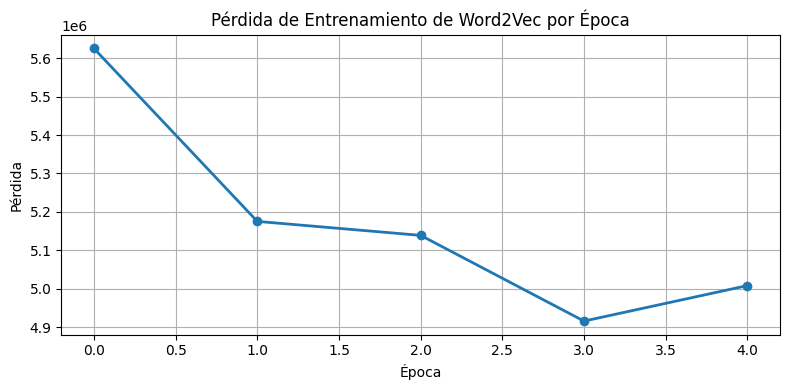

PASO 4: Generación de fichero de palabras similares
[INFO] Palabras similares escritas en 'similar_words.txt'.
Puedes abrir el fichero 'similar_words.txt' para inspeccionar la calidad del modelo.

PASO 5: Visualización de embeddings con PCA


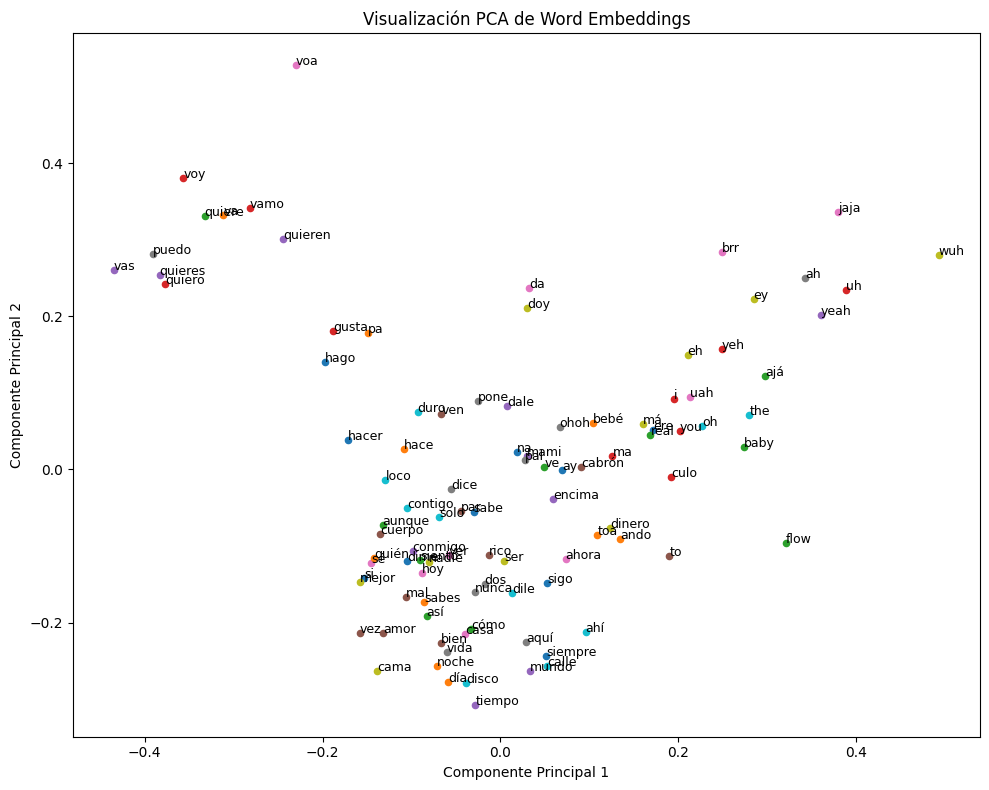

PASO 6: Exportación a TSV para TensorFlow Projector
[INFO] Ficheros TSV escritos: 'vecs.tsv' y 'meta.tsv'.
Sube vecs.tsv y meta.tsv a https://projector.tensorflow.org/ para exploración interactiva.


In [9]:
# ── Rutas de ficheros ─────────────────────────────────────────────────────────
# Ajusta CORPUS_FILE a la ruta donde hayas subido el corpus en Colab.
CORPUS_FILE  = "/content/corpusD.txt"       # Corpus de letras de canciones.
MODEL_PATH   = "word2vec.model"             # Modelo completo de gensim (binario).
VECTORS_PATH = "word2vec_vectors.txt"       # Solo los vectores (formato texto).
SIMILAR_FILE = "similar_words.txt"          # Palabras similares por cada token.

# ── Paso 1: Lectura y tokenización del corpus ─────────────────────────────────
print("=" * 60)
print("PASO 1: Lectura y tokenización del corpus")
print("=" * 60)
# Leemos el corpus y lo convertimos en una lista de oraciones tokenizadas.
# Aplicamos nuestra función 'preprocess' para normalizar el texto.
sentences, songs = read_and_tokenize_wordvec(CORPUS_FILE, preprocess_fn=preprocess)
print(f"Ejemplo de primera oración: {sentences[0][:10]}...\n")

# ── Paso 2: Entrenamiento del modelo Word2Vec ─────────────────────────────────
print("=" * 60)
print("PASO 2: Entrenamiento del modelo Word2Vec")
print("=" * 60)
model, losses = train_word2vec(
    sentences,
    vector_size=100,   # Cada palabra se representará como un vector de 100 dimensiones.
    window=5,          # El modelo analiza las 5 palabras anteriores y posteriores.
    min_count=10,      # Ignoramos palabras que aparecen menos de 10 veces.
    epochs=5,         # 20 pasadas completas sobre el corpus.
    sg=1,              # Arquitectura Skip-Gram.
    negative=10,       # 10 muestras negativas por cada par (palabra, contexto).
    save_path=MODEL_PATH,
    save_txt_path=VECTORS_PATH,
)

# ── Paso 3: Visualización de la curva de pérdida ──────────────────────────────
print("\n" + "=" * 60)
print("PASO 3: Curva de pérdida por época")
print("=" * 60)
# Una pérdida decreciente indica que el modelo está aprendiendo.
# Si la curva se aplana, el modelo ha convergido.
plot_training_loss(losses)

# ── Paso 4: Fichero de palabras similares ─────────────────────────────────────
print("=" * 60)
print("PASO 4: Generación de fichero de palabras similares")
print("=" * 60)
# Para cada palabra del vocabulario, buscamos las 10 más cercanas.
write_most_similar_words_gensim(model, SIMILAR_FILE, topn=10)
print("Puedes abrir el fichero 'similar_words.txt' para inspeccionar la calidad del modelo.\n")

# ── Paso 5: Visualización de embeddings ──────────────────────────────────────
print("=" * 60)
print("PASO 5: Visualización de embeddings con PCA")
print("=" * 60)
# Palabras semánticamente relacionadas deberían aparecer agrupadas.
visualize_embeddings_gensim(model, min_frequency=2, method="pca")

# Descomenta la siguiente línea para visualizar con t-SNE (más lento pero mejor):
# visualize_embeddings_gensim(model, min_frequency=2, method="tsne")

# ── Paso 6: Exportación a TSV para TensorFlow Projector ───────────────────────
print("=" * 60)
print("PASO 6: Exportación a TSV para TensorFlow Projector")
print("=" * 60)
write_tsv(VECTORS_PATH, vecs_out="vecs.tsv", meta_out="meta.tsv")
print("Sube vecs.tsv y meta.tsv a https://projector.tensorflow.org/ para exploración interactiva.")

---
## Preguntas de reflexión y ejercicios opcionales

Una vez completado el pipeline básico, explora las siguientes cuestiones:

1. **Efecto de la arquitectura**: Entrena el mismo corpus con CBOW (`sg=0`) y compara los embeddings resultantes con los de Skip-Gram (`sg=1`). ¿Qué diferencias observas en las palabras similares?

2. **Efecto del tamaño de ventana**: Prueba con `window=2` y `window=10`. ¿Qué tipo de relaciones captura mejor cada configuración?

3. **Analogías vectoriales**: El espacio de embeddings permite operaciones de analogía. Prueba:  
   ```python
   model.wv.most_similar(positive=['amor', 'pasado'], negative=['presente'])
   ```
   ¿El modelo aprende estas relaciones con el corpus de canciones?

4. **Hierarchical Softmax vs. Negative Sampling**: Entrena con `hs=1, negative=0` y compara calidad y tiempo de entrenamiento.

5. **TensorFlow Projector**: Carga los ficheros TSV en https://projector.tensorflow.org/ y explora los clusters en 3D. ¿Qué grupos temáticos identificas?